In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from pathlib import Path
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
import seaborn as sns
import json

from src.utils.paths import load_paths
from src.utils.logging import setup_logger

from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.eval.metrics import binary_metrics
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.splits.io import load_splits

paths = load_paths()
paths.ensure_dirs()
logger = setup_logger(level="INFO")

logger.info(f"Repo root: {paths.repo_root}")
logger.info(f"Processed dir: {paths.data_processed}")
logger.info(f"Configs dir: {paths.configs_dir}")
logger.info(f"Artifacts dir: {paths.artifacts_dir}")


2026-03-13 12:27:47 | INFO | ai-vpn-firewall | Repo root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall
2026-03-13 12:27:47 | INFO | ai-vpn-firewall | Processed dir: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed
2026-03-13 12:27:47 | INFO | ai-vpn-firewall | Configs dir: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\configs
2026-03-13 12:27:47 | INFO | ai-vpn-firewall | Artifacts dir: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts


In [2]:
features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

logger.info("Loading flows...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")

logger.info("Extracting features from flows (VNAT)...")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

logger.info("Extracting features from flows (ISCX)...")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

# --- UPDATED: Load Canonical Splits ---
def apply_split_lists(df, train_list, val_list, test_list, split_col="split"):
    splits = load_splits(train_list, val_list, test_list)

    cap_to_split = {}
    for split_name, caps in splits.items():
        for cid in caps:
            cap_to_split[str(cid)] = split_name

    out = df.copy()
    out["capture_id"] = out["capture_id"].astype(str)
    out[split_col] = out["capture_id"].map(cap_to_split)

    missing_caps = sorted(out.loc[out[split_col].isna(), "capture_id"].unique().tolist())
    if missing_caps:
        raise ValueError(
            f"Found {len(missing_caps)} captures without split assignment. "
            f"Examples: {missing_caps[:10]}"
        )

    return out

logger.info("Applying canonical splits...")

vnat_feats = apply_split_lists(
    vnat_feats,
    paths.data_splits / "vnat_train_captures.txt",
    paths.data_splits / "vnat_val_captures.txt",
    paths.data_splits / "vnat_test_captures.txt",
)

iscx_feats = apply_split_lists(
    iscx_feats,
    paths.data_splits / "iscx_train_captures.txt",
    paths.data_splits / "iscx_val_captures.txt",
    paths.data_splits / "iscx_test_captures.txt",
)

# Filter min packets
if "q_min_packets_ok" in vnat_feats.columns:
    vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()
if "q_min_packets_ok" in iscx_feats.columns:
    iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)

logger.info(f"Combined df_all: {df_all.shape}, columns={len(df_all.columns)}")
print("Final splits:")
print(df_all["split"].value_counts())


2026-03-13 12:27:47 | INFO | ai-vpn-firewall | Loading flows...
2026-03-13 12:27:48 | INFO | ai-vpn-firewall | Extracting features from flows (VNAT)...
2026-03-13 12:28:52 | INFO | ai-vpn-firewall | Extracting features from flows (ISCX)...
2026-03-13 12:29:47 | INFO | ai-vpn-firewall | Applying canonical splits...
2026-03-13 12:29:47 | INFO | ai-vpn-firewall | Combined df_all: (19908, 45), columns=45
Final splits:
split
train    16138
val       1926
test      1844
Name: count, dtype: int64


In [3]:
# --- A) Label Sanity Check ---
def label_sanity(flows, name):
    print("\n" + "="*60)
    print(f"LABEL SANITY: {name}")
    print("="*60)

    # Basic distribution
    print("Flow-level label distribution:")
    print(flows["label"].value_counts(normalize=True))

    # Compare capture name prefix vs label mean
    flows = flows.copy()
    flows["is_vpn_prefix"] = flows["capture_id"].astype(str).str.startswith("vpn_").astype(int)

    by_cap = flows.groupby("capture_id").agg(
        n=("label", "size"),
        label_mean=("label", "mean"),
        prefix=("is_vpn_prefix", "max")
    ).reset_index()

    print("\nCaptures where prefix says VPN but labels are mostly 0:")
    print(by_cap[(by_cap["prefix"]==1) & (by_cap["label_mean"] < 0.5)].head(20))

    print("\nCaptures where prefix says NONVPN but labels are mostly 1:")
    print(by_cap[(by_cap["prefix"]==0) & (by_cap["label_mean"] > 0.5)].head(20))

label_sanity(vnat_flows, "VNAT")
label_sanity(iscx_flows, "ISCX")



LABEL SANITY: VNAT
Flow-level label distribution:
label
0    0.988757
1    0.011243
Name: proportion, dtype: float64

Captures where prefix says VPN but labels are mostly 0:
Empty DataFrame
Columns: [capture_id, n, label_mean, prefix]
Index: []

Captures where prefix says NONVPN but labels are mostly 1:
Empty DataFrame
Columns: [capture_id, n, label_mean, prefix]
Index: []

LABEL SANITY: ISCX
Flow-level label distribution:
label
0    0.707473
1    0.292527
Name: proportion, dtype: float64

Captures where prefix says VPN but labels are mostly 0:
Empty DataFrame
Columns: [capture_id, n, label_mean, prefix]
Index: []

Captures where prefix says NONVPN but labels are mostly 1:
Empty DataFrame
Columns: [capture_id, n, label_mean, prefix]
Index: []


In [4]:
# --- B) Feature Shift Check ---
def compare_feature_stats(df_all, feat, label=1):
    sub_v = df_all[(df_all["dataset"]=="vnat") & (df_all["label"]==label)]
    sub_i = df_all[(df_all["dataset"]=="iscx") & (df_all["label"]==label)]

    print("\n" + "="*60)
    print(f"FEATURE SHIFT CHECK: {feat} (label={label})")
    print("="*60)

    for name, sub in [("VNAT", sub_v), ("ISCX", sub_i)]:
        if sub.empty or feat not in sub.columns:
            print(f"{name}: missing")
            continue
        print(f"{name}: n={len(sub)} mean={sub[feat].mean():.4f} std={sub[feat].std():.4f} "
              f"p25={sub[feat].quantile(0.25):.4f} p50={sub[feat].median():.4f} p75={sub[feat].quantile(0.75):.4f}")

# Check key features that might flip with direction
for f in ["sz_mean_max", "sz_mean_min", "iat_mean_max", "iat_mean_min"]:
    compare_feature_stats(df_all, f, label=1)
    compare_feature_stats(df_all, f, label=0)



FEATURE SHIFT CHECK: sz_mean_max (label=1)
VNAT: n=374 mean=117.4056 std=154.0235 p25=52.0000 p50=52.0000 p75=56.0000
ISCX: n=2943 mean=370.1382 std=413.6652 p25=77.3333 p50=155.0769 p75=504.5646

FEATURE SHIFT CHECK: sz_mean_max (label=0)
VNAT: n=7733 mean=246.2471 std=292.2726 p25=63.0000 p50=75.0000 p75=323.0667
ISCX: n=8858 mean=350.9922 std=713.7107 p25=91.6667 p50=150.0000 p75=341.0000

FEATURE SHIFT CHECK: sz_mean_min (label=1)
VNAT: n=374 mean=56.7005 std=110.4778 p25=0.0000 p50=0.0000 p75=0.0000
ISCX: n=2943 mean=98.2097 std=113.2478 p25=50.0000 p50=67.8182 p75=104.3611

FEATURE SHIFT CHECK: sz_mean_min (label=0)
VNAT: n=7733 mean=108.6074 std=78.6092 p25=55.0000 p50=63.0000 p75=140.0244
ISCX: n=8858 mean=98.4082 std=117.5108 p25=0.0000 p50=68.6667 p75=130.9444

FEATURE SHIFT CHECK: iat_mean_max (label=1)
VNAT: n=374 mean=3.7705 std=1.4204 p25=4.4996 p50=4.5002 p75=4.5006
ISCX: n=2943 mean=12.4776 std=51.7214 p25=0.0315 p50=0.4448 p75=6.8666

FEATURE SHIFT CHECK: iat_mean_max

In [5]:
# --- C) Cross-Domain Sign Flip Diagnostic ---
def threshold_sweep(y, p, tag=""):
    print(f"\n--- Threshold Sweep: {tag} ---")
    for thr in [0.1, 0.3, 0.5, 0.7, 0.9]:
        acc = accuracy_score(y, (p >= thr).astype(int))
        acc_inv = accuracy_score(y, ((1-p) >= thr).astype(int))
        print(f"{tag} thr={thr:.1f}: acc(p)={acc:.3f} acc(1-p)={acc_inv:.3f}")

def smoke_cross_domain_sweep(df_all):
    print("\n=== C) Cross-domain Sign Flip Diagnostic ===")

    df_vnat_train = df_all[(df_all["dataset"] == "vnat") & (df_all["split"] == "train")].copy()
    df_iscx_test = df_all[(df_all["dataset"] == "iscx") & (df_all["split"] == "test")].copy()

    if df_vnat_train.empty or df_iscx_test.empty:
        print("Skipping cross-domain test: missing data.")
        return

    pipe_vnat = FeaturePipeline().fit(df_vnat_train)
    feat_cols = pipe_vnat.model_feature_names()

    X_vnat = pipe_vnat.transform(df_vnat_train)
    X_iscx = pipe_vnat.transform(df_iscx_test)

    y_vnat = df_vnat_train["label"].values
    y_iscx = df_iscx_test["label"].values

    model = xgb.XGBClassifier(
        n_estimators=30,
        max_depth=3,
        learning_rate=0.1,
        n_jobs=4,
        eval_metric="auc",
        random_state=42
    )
    model.fit(X_vnat[feat_cols], y_vnat)

    preds = model.predict_proba(X_iscx[feat_cols])[:, 1]

    auc = roc_auc_score(y_iscx, preds)
    print(f"VNAT->ISCX AUC: {auc:.4f}")

    threshold_sweep(y_iscx, preds, tag="VNAT->ISCX")

    # --- NEW: Confusion Matrix at Firewall Threshold ---
    # We use binary_metrics to get policy thresholds (computed on this test set, optimistic but useful for check)
    metrics = binary_metrics(y_iscx, preds, threshold=0.5, compute_policy_thresholds=True)

    print("\n--- Confusion Matrix at Firewall Threshold (VNAT->ISCX) ---")
    if "policy_thresholds" in metrics:
        # Check for Block (0.1%) and Monitor (1%)
        for key in ["fpr_0_1pct", "fpr_1pct"]:
            if key in metrics["policy_thresholds"]:
                m = metrics["policy_thresholds"][key]
                print(f"\nPolicy: {key} (Threshold: {m['threshold']:.4f})")
                cm = m['confusion_matrix']
                print(f"  Confusion Matrix: TN={cm['tn']}, FP={cm['fp']}, FN={cm['fn']}, TP={cm['tp']}")
                print(f"  Precision: {m['precision']:.4f}, Recall: {m['recall']:.4f}")

smoke_cross_domain_sweep(df_all)



=== C) Cross-domain Sign Flip Diagnostic ===
VNAT->ISCX AUC: 0.1613

--- Threshold Sweep: VNAT->ISCX ---
VNAT->ISCX thr=0.1: acc(p)=0.603 acc(1-p)=0.145
VNAT->ISCX thr=0.3: acc(p)=0.688 acc(1-p)=0.157
VNAT->ISCX thr=0.5: acc(p)=0.714 acc(1-p)=0.286
VNAT->ISCX thr=0.7: acc(p)=0.843 acc(1-p)=0.312
VNAT->ISCX thr=0.9: acc(p)=0.855 acc(1-p)=0.397

--- Confusion Matrix at Firewall Threshold (VNAT->ISCX) ---

Policy: fpr_1pct (Threshold: 0.7788)
  Confusion Matrix: TN=1382, FP=14, FN=232, TP=6
  Precision: 0.3000, Recall: 0.0252


In [6]:
# --- D) Refined Leave-One-App-Out (LOAO) ---
print("\n=== D) Refined Leave-One-App-Out (LOAO) ===")

# 1. Map capture_id -> app
def make_capture_to_app_map(flows: pd.DataFrame) -> pd.Series:
    if "app" not in flows.columns:
        return pd.Series(dtype=str)
    def mode_or_unknown(x):
        x = x.dropna()
        if len(x) == 0: return "unknown"
        return x.value_counts().idxmax()
    return flows.groupby("capture_id")["app"].apply(mode_or_unknown)

cap2app_vnat = make_capture_to_app_map(vnat_flows)
cap2app_iscx = make_capture_to_app_map(iscx_flows)
cap2app = pd.concat([cap2app_vnat, cap2app_iscx])

df_all["app"] = df_all["capture_id"].map(cap2app).fillna("unknown")

# 2. Normalize app names
df_all["app"] = (
    df_all["app"].astype(str)
    .str.lower()
    .str.strip()
    .replace({
        "skype_video": "skype",
        "skype_audio": "skype",
        "facebook_audio": "facebook",
        "facebook_chat": "facebook",
        "aim_chat": "aim",
        "icq_chat": "icq",
        "gmail_chat": "gmail",
        "hangouts_chat": "hangouts",
    }, regex=True)
)
# Manual overrides for known patterns
df_all.loc[df_all["app"].str.contains("skype"), "app"] = "skype"
df_all.loc[df_all["app"].str.contains("facebook"), "app"] = "facebook"
df_all.loc[df_all["app"].str.contains("netflix"), "app"] = "netflix"
df_all.loc[df_all["app"].str.contains("youtube"), "app"] = "youtube"
df_all.loc[df_all["app"].str.contains("spotify"), "app"] = "spotify"
df_all.loc[df_all["app"].str.contains("vimeo"), "app"] = "vimeo"
df_all.loc[df_all["app"].str.contains("bittorrent"), "app"] = "bittorrent"

# 3. Run LOAO on TRAIN split only
df_train_loao = df_all[df_all["split"] == "train"].copy()
apps = sorted([a for a in df_train_loao["app"].unique() if a != "unknown"])

MIN_N = 200
MIN_POS = 20

loao_results = []
print(f"Testing {len(apps)} apps: {apps}")

for holdout_app in apps:
    # Hold out ALL captures for this app
    train_df = df_train_loao[df_train_loao["app"] != holdout_app].copy()
    test_df  = df_train_loao[df_train_loao["app"] == holdout_app].copy()

    # Guardrails
    if len(test_df) < MIN_N:
        # print(f"Skipping {holdout_app}: n={len(test_df)} < {MIN_N}")
        continue

    n_pos = test_df["label"].sum()
    n_neg = (test_df["label"] == 0).sum()

    if n_pos < MIN_POS or n_neg < MIN_POS:
        # print(f"Skipping {holdout_app}: unbalanced (pos={n_pos}, neg={n_neg})")
        continue

    pipe_loao = FeaturePipeline().fit(train_df)
    feats_loao = pipe_loao.model_feature_names()

    X_tr = pipe_loao.transform(train_df)[feats_loao]
    y_tr = train_df["label"].astype(int)

    X_te = pipe_loao.transform(test_df)[feats_loao]
    y_te = test_df["label"].astype(int)

    model_loao = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        random_state=42,
        n_jobs=4,
    )
    model_loao.fit(X_tr, y_tr)

    p = model_loao.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, p)

    loao_results.append({
        "app": holdout_app,
        "n_test": len(test_df),
        "pos_rate": float(y_te.mean()),
        "auc": float(auc)
    })
    print(f"LOAO app={holdout_app:>15s} | n={len(test_df):4d} | AUC={auc:.4f}")

if loao_results:
    res_df = pd.DataFrame(loao_results).sort_values("auc")
    print("\nLOAO Summary (Worst 10):")
    print(res_df.head(10).to_string(index=False))
    print(f"\nMacro Mean AUC: {res_df['auc'].mean():.4f}")
else:
    print("No valid LOAO runs passed the filters.")



=== D) Refined Leave-One-App-Out (LOAO) ===
Testing 47 apps: ['aim', 'email2a', 'facebook', 'ftps', 'hangouts', 'icq', 'netflix', 'nonaim', 'nonaimchat1', 'nonaimchat2', 'nonemail1a', 'nonemail1b', 'nonemail2a', 'nonemail2b', 'nonftps', 'nongmailchat1', 'nongmailchat2', 'nongmailchat3', 'nonhangout', 'nonhangouts', 'nonicq', 'nonscp1', 'nonscpdown1', 'nonscpdown2', 'nonscpdown3', 'nonscpdown4', 'nonscpdown5', 'nonscpdown6', 'nonscpup1', 'nonscpup3', 'nonscpup5', 'nonsftp', 'nonsftpdown1', 'nonsftpup1', 'nonvoipbuster', 'nonvoipbuster1b', 'nonvoipbuster2b', 'rdp', 'rsync', 'scp', 'sftp', 'skype', 'spotify', 'ssh', 'vimeo', 'voip', 'youtube']
LOAO app=       facebook | n=1413 | AUC=0.9787
LOAO app=        netflix | n= 447 | AUC=0.9970
LOAO app=           sftp | n= 606 | AUC=0.9974
LOAO app=          skype | n=2750 | AUC=0.9341
LOAO app=          vimeo | n=1516 | AUC=0.9839
LOAO app=        youtube | n= 682 | AUC=0.9468

LOAO Summary (Worst 10):
     app  n_test  pos_rate      auc
   sky

In [7]:
# --- E) Dataset Detector (Step 3) ---
print("\n=== E) Dataset Detector (VNAT vs ISCX) ===")
# Train a model to predict the DATASET (0=VNAT, 1=ISCX)
# If AUC is high, features strongly encode the domain.

df_train_ds = df_all[df_all["split"] == "train"].copy()
df_train_ds["target_ds"] = (df_train_ds["dataset"] == "iscx").astype(int)

# FIX: Drop target_ds before fitting pipeline to avoid leakage
df_train_for_pipe = df_train_ds.drop(columns=["target_ds"])

pipe_ds = FeaturePipeline().fit(df_train_for_pipe)
feats_ds = pipe_ds.model_feature_names()

# FIX: Transform the clean dataframe (without target_ds)
X_ds = pipe_ds.transform(df_train_for_pipe)[feats_ds]
y_ds = df_train_ds["target_ds"]

model_ds = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="auc",
    random_state=42,
    n_jobs=4
)
model_ds.fit(X_ds, y_ds)

# Evaluate on Test split (to be fair)
df_test_ds = df_all[df_all["split"] == "test"].copy()
df_test_ds["target_ds"] = (df_test_ds["dataset"] == "iscx").astype(int)

# FIX: Drop target_ds from test set too before transform
df_test_for_pipe = df_test_ds.drop(columns=["target_ds"])
X_test_ds = pipe_ds.transform(df_test_for_pipe)[feats_ds]
y_test_ds = df_test_ds["target_ds"]

p_ds = model_ds.predict_proba(X_test_ds)[:, 1]
auc_ds = roc_auc_score(y_test_ds, p_ds)

print(f"Dataset Prediction AUC (VNAT vs ISCX): {auc_ds:.4f}")
if auc_ds > 0.8:
    print("WARNING: High AUC indicates features strongly identify the dataset (Domain Shift).")

# Feature Importance
imp = pd.DataFrame({
    "feature": feats_ds,
    "importance": model_ds.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 10 'Dataset Detector' Features:")
print(imp.head(10).to_string(index=False))



=== E) Dataset Detector (VNAT vs ISCX) ===
Dataset Prediction AUC (VNAT vs ISCX): 0.9953

Top 10 'Dataset Detector' Features:
       feature  importance
iat_all_median    0.169682
 h_size_all_00    0.146250
    sz_all_p25    0.084758
   iat_all_p75    0.062775
    sz_all_std    0.048822
    sz_std_min    0.042240
  iat_all_mean    0.041491
  h_iat_all_11    0.037074
   iat_std_max    0.031702
  iat_mean_min    0.028308



=== F) Skewness and Kurtosis Analysis ===

Top 10 Features with Largest Skewness Difference (VNAT vs ISCX):
                vnat_skew  iscx_skew  skew_diff
h_size_all_06   89.796369   6.867885  82.928484
iat_all_median  64.391882   5.450233  58.941649
iat_all_p25     57.109926   7.343520  49.766406
sz_all_p25      25.546976   9.415279  16.131697
h_iat_all_10    13.841724   2.979558  10.862166
sz_std_max       0.669898  10.200446   9.530548
sz_all_std       0.846341   7.725302   6.878961
sz_mean_max      1.928213   8.643149   6.714936
h_iat_all_04     2.692671   7.410921   4.718250
h_iat_all_09     7.909370   3.267607   4.641763

Top 10 Features with Largest Kurtosis Difference (VNAT vs ISCX):
                  vnat_kurt   iscx_kurt    kurt_diff
h_size_all_06   8077.309674   52.628381  8024.681293
iat_all_median  4450.184246   37.511037  4412.673209
iat_all_p25     3431.597771   60.470102  3371.127669
sz_all_p25       805.936451  116.899844   689.036606
h_iat_all_10     343.721024   11

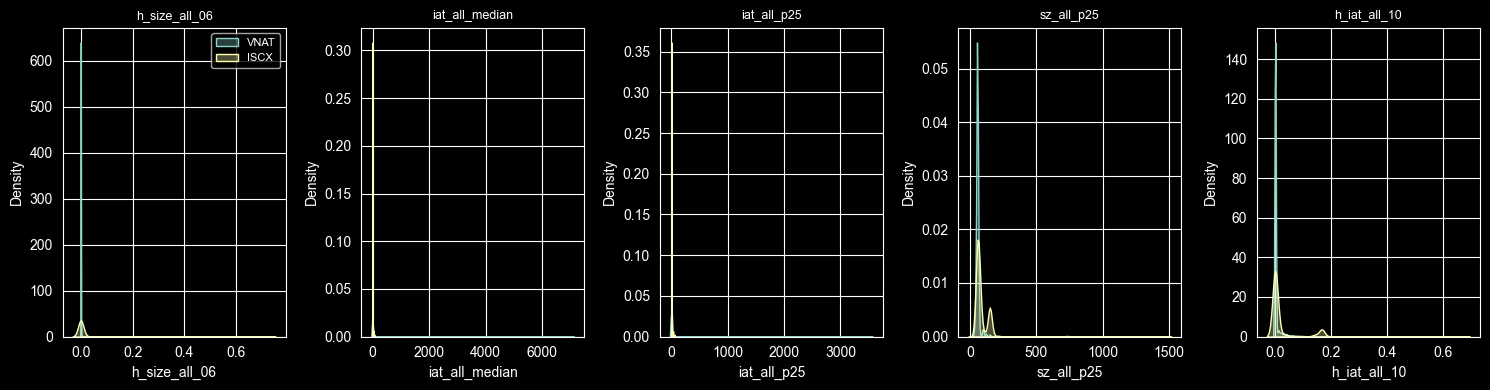


--- VNAT Distributions (Skewness Top 5) ---


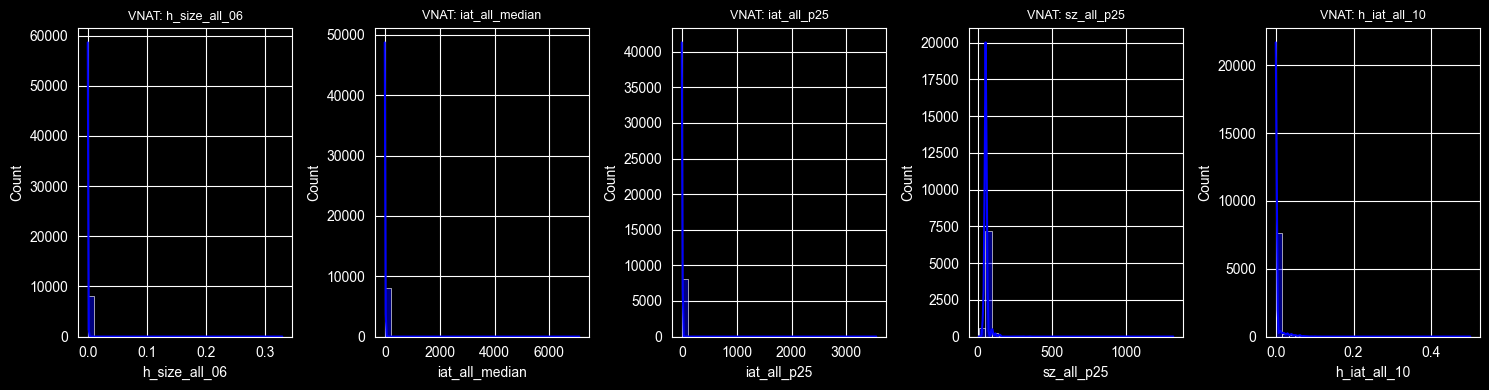


--- ISCX Distributions (Skewness Top 5) ---


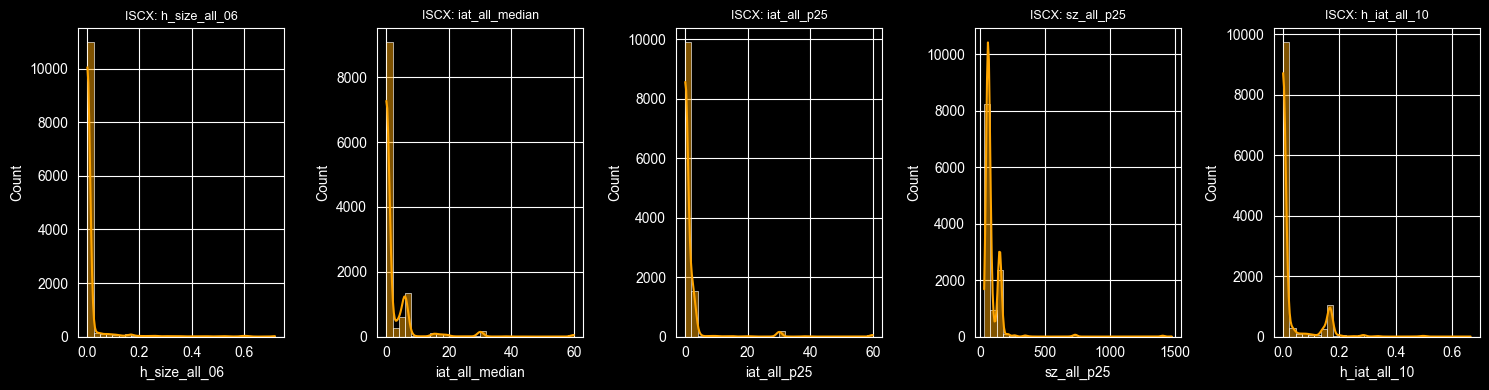


--- Combined Distributions (Skewness Top 5) ---


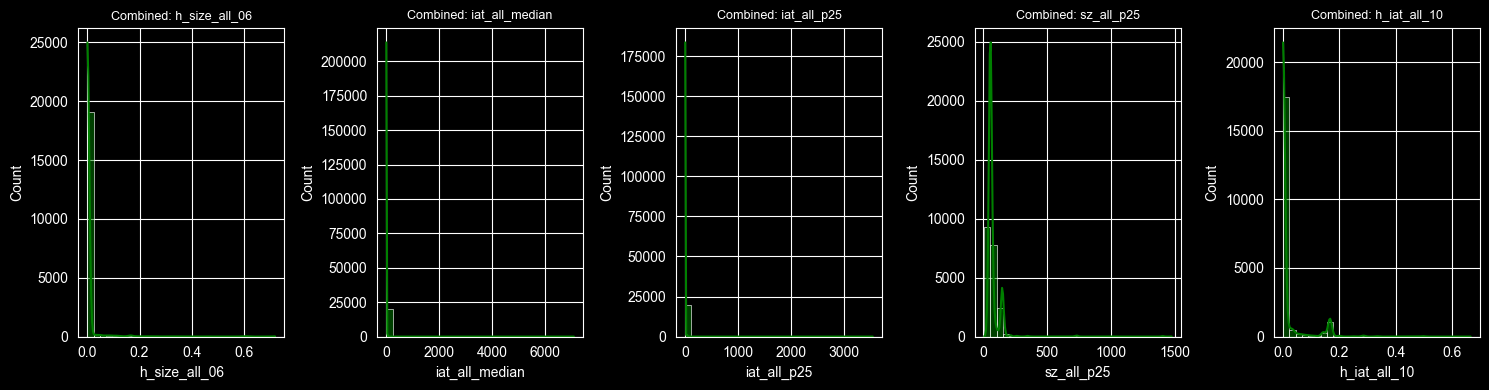


--- Overlay Distributions (Kurtosis Top 5) ---


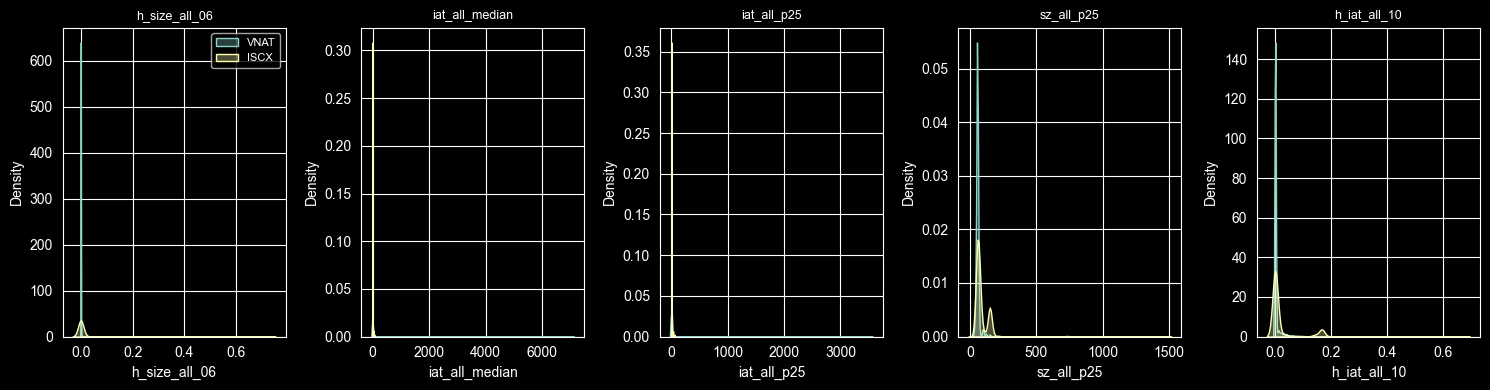


--- VNAT Distributions (Kurtosis Top 5) ---


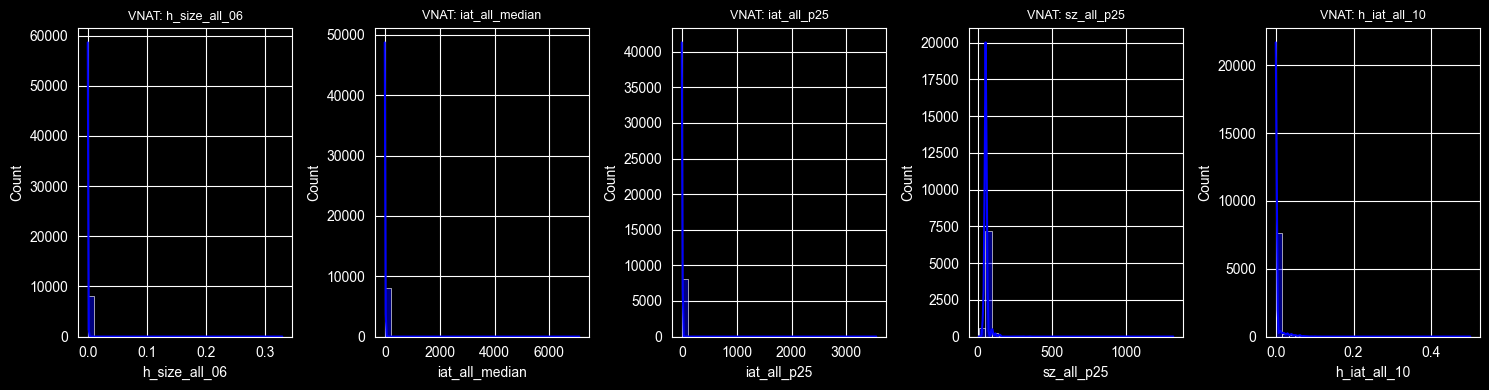


--- ISCX Distributions (Kurtosis Top 5) ---


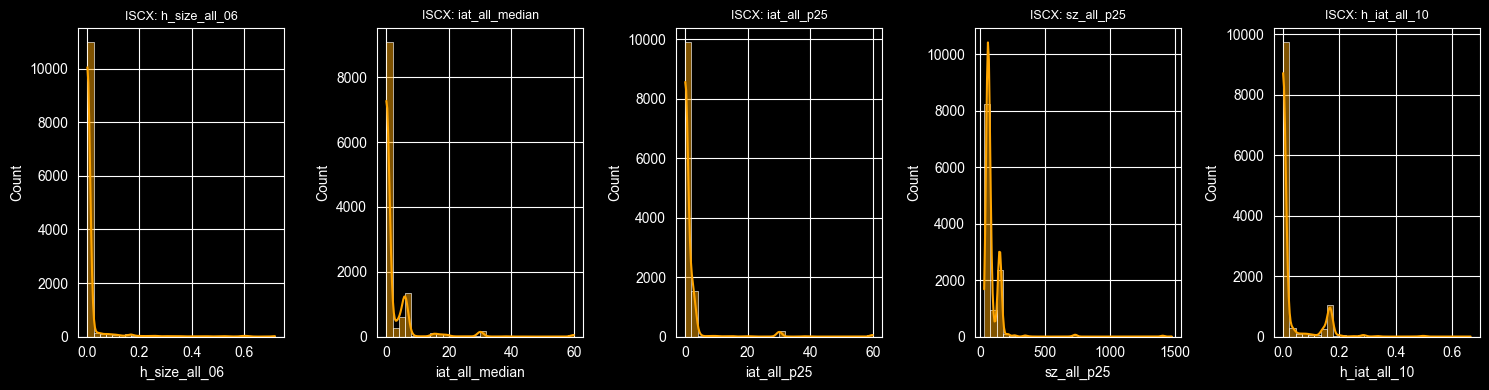


--- Combined Distributions (Kurtosis Top 5) ---


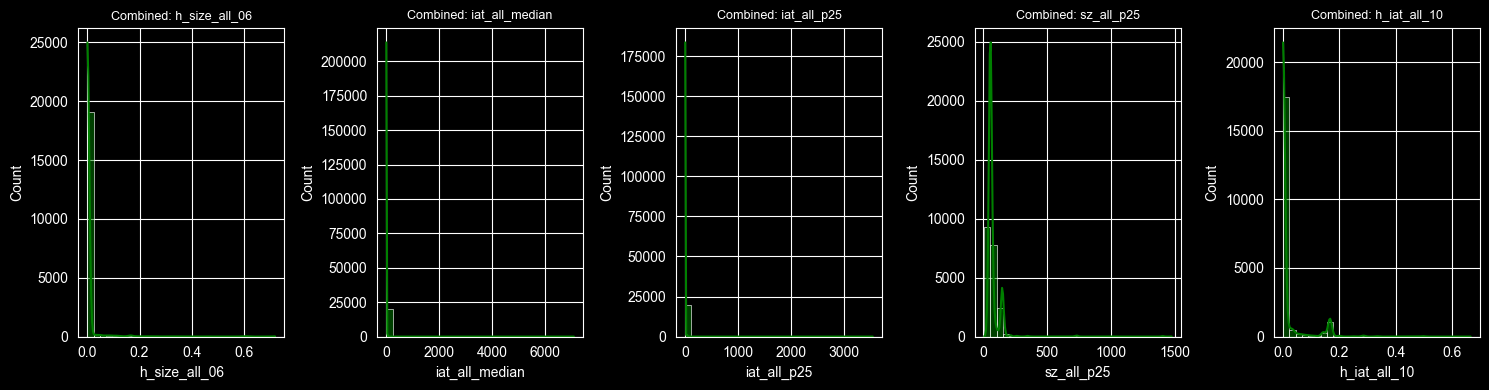

In [8]:
# --- F) Skewness and Kurtosis Analysis (New) ---
print("\n=== F) Skewness and Kurtosis Analysis ===")

# Select numeric feature columns
numeric_cols = df_all.select_dtypes(include=[np.number]).columns
# Exclude metadata and targets
exclude_cols = {"label", "q_min_packets_ok", "sample_weight", "target_ds"}
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

# Compute stats per dataset
stats_vnat = df_all[df_all["dataset"] == "vnat"][feature_cols].agg(["skew", "kurt"]).T
stats_iscx = df_all[df_all["dataset"] == "iscx"][feature_cols].agg(["skew", "kurt"]).T
stats_all = df_all[feature_cols].agg(["skew", "kurt"]).T

# Rename columns for clarity
stats_vnat.columns = ["vnat_skew", "vnat_kurt"]
stats_iscx.columns = ["iscx_skew", "iscx_kurt"]
stats_all.columns = ["all_skew", "all_kurt"]

# Combine
stats_combined = pd.concat([stats_vnat, stats_iscx, stats_all], axis=1)

# Calculate differences
stats_combined["skew_diff"] = (stats_combined["vnat_skew"] - stats_combined["iscx_skew"]).abs()
stats_combined["kurt_diff"] = (stats_combined["vnat_kurt"] - stats_combined["iscx_kurt"]).abs()

# Sort by biggest skew difference
print("\nTop 10 Features with Largest Skewness Difference (VNAT vs ISCX):")
print(stats_combined.sort_values("skew_diff", ascending=False).head(10)[["vnat_skew", "iscx_skew", "skew_diff"]])

# Sort by biggest kurtosis difference
print("\nTop 10 Features with Largest Kurtosis Difference (VNAT vs ISCX):")
print(stats_combined.sort_values("kurt_diff", ascending=False).head(10)[["vnat_kurt", "iscx_kurt", "kurt_diff"]])

# NEW: Print Top 10 Skewed/Kurtotic for EACH dataset individually
print("\n--- Top 10 Skewed Features (VNAT) ---")
print(stats_vnat.sort_values("vnat_skew", key=abs, ascending=False).head(10))

print("\n--- Top 10 Skewed Features (ISCX) ---")
print(stats_iscx.sort_values("iscx_skew", key=abs, ascending=False).head(10))

print("\n--- Top 10 Kurtotic Features (VNAT) ---")
print(stats_vnat.sort_values("vnat_kurt", key=abs, ascending=False).head(10))

print("\n--- Top 10 Kurtotic Features (ISCX) ---")
print(stats_iscx.sort_values("iscx_kurt", key=abs, ascending=False).head(10))

# Visualization (Skewness)
top_skew_feats = stats_combined.sort_values("skew_diff", ascending=False).head(5).index

# 1. Overlay Plot (Skew)
print("\n--- Overlay Distributions (Skewness Top 5) ---")
plt.figure(figsize=(15, 4))
for i, feat in enumerate(top_skew_feats):
    plt.subplot(1, 5, i+1)
    sns.kdeplot(df_all[df_all["dataset"]=="vnat"][feat], label="VNAT", fill=True, alpha=0.3)
    sns.kdeplot(df_all[df_all["dataset"]=="iscx"][feat], label="ISCX", fill=True, alpha=0.3)
    plt.title(feat, fontsize=9)
    if i == 0: plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 2. Individual Plots (VNAT - Skew)
print("\n--- VNAT Distributions (Skewness Top 5) ---")
plt.figure(figsize=(15, 4))
for i, feat in enumerate(top_skew_feats):
    plt.subplot(1, 5, i+1)
    sns.histplot(df_all[df_all["dataset"]=="vnat"][feat], kde=True, color="blue", bins=30)
    plt.title(f"VNAT: {feat}", fontsize=9)
plt.tight_layout()
plt.show()

# 3. Individual Plots (ISCX - Skew)
print("\n--- ISCX Distributions (Skewness Top 5) ---")
plt.figure(figsize=(15, 4))
for i, feat in enumerate(top_skew_feats):
    plt.subplot(1, 5, i+1)
    sns.histplot(df_all[df_all["dataset"]=="iscx"][feat], kde=True, color="orange", bins=30)
    plt.title(f"ISCX: {feat}", fontsize=9)
plt.tight_layout()
plt.show()

# 4. Individual Plots (Combined - Skew)
print("\n--- Combined Distributions (Skewness Top 5) ---")
plt.figure(figsize=(15, 4))
for i, feat in enumerate(top_skew_feats):
    plt.subplot(1, 5, i+1)
    sns.histplot(df_all[feat], kde=True, color="green", bins=30)
    plt.title(f"Combined: {feat}", fontsize=9)
plt.tight_layout()
plt.show()

# Visualization (Kurtosis)
top_kurt_feats = stats_combined.sort_values("kurt_diff", ascending=False).head(5).index

# 1. Overlay Plot (Kurtosis)
print("\n--- Overlay Distributions (Kurtosis Top 5) ---")
plt.figure(figsize=(15, 4))
for i, feat in enumerate(top_kurt_feats):
    plt.subplot(1, 5, i+1)
    sns.kdeplot(df_all[df_all["dataset"]=="vnat"][feat], label="VNAT", fill=True, alpha=0.3)
    sns.kdeplot(df_all[df_all["dataset"]=="iscx"][feat], label="ISCX", fill=True, alpha=0.3)
    plt.title(feat, fontsize=9)
    if i == 0: plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 2. Individual Plots (VNAT - Kurtosis)
print("\n--- VNAT Distributions (Kurtosis Top 5) ---")
plt.figure(figsize=(15, 4))
for i, feat in enumerate(top_kurt_feats):
    plt.subplot(1, 5, i+1)
    sns.histplot(df_all[df_all["dataset"]=="vnat"][feat], kde=True, color="blue", bins=30)
    plt.title(f"VNAT: {feat}", fontsize=9)
plt.tight_layout()
plt.show()

# 3. Individual Plots (ISCX - Kurtosis)
print("\n--- ISCX Distributions (Kurtosis Top 5) ---")
plt.figure(figsize=(15, 4))
for i, feat in enumerate(top_kurt_feats):
    plt.subplot(1, 5, i+1)
    sns.histplot(df_all[df_all["dataset"]=="iscx"][feat], kde=True, color="orange", bins=30)
    plt.title(f"ISCX: {feat}", fontsize=9)
plt.tight_layout()
plt.show()

# 4. Individual Plots (Combined - Kurtosis)
print("\n--- Combined Distributions (Kurtosis Top 5) ---")
plt.figure(figsize=(15, 4))
for i, feat in enumerate(top_kurt_feats):
    plt.subplot(1, 5, i+1)
    sns.histplot(df_all[feat], kde=True, color="green", bins=30)
    plt.title(f"Combined: {feat}", fontsize=9)
plt.tight_layout()
plt.show()


AFTER TRAINING THE MODEL PLOTS


=== G) Final Model Performance Check (Post-Flight) ===
2026-03-13 12:30:01 | INFO | ai-vpn-firewall | Loading final ensemble predictions and metrics...
Raw and calibrated probabilities are both available.
Global Thresholds: BLOCK=0.9900, MONITOR=0.9900

--- Ensemble ROC/PR Curves (All Splits) ---


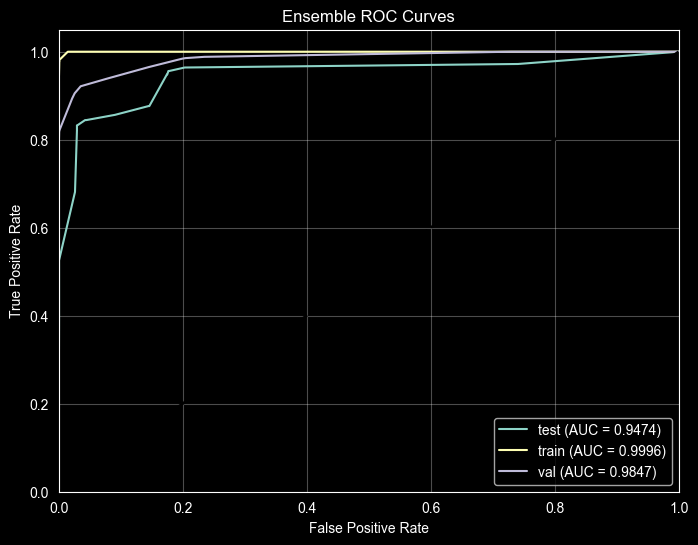

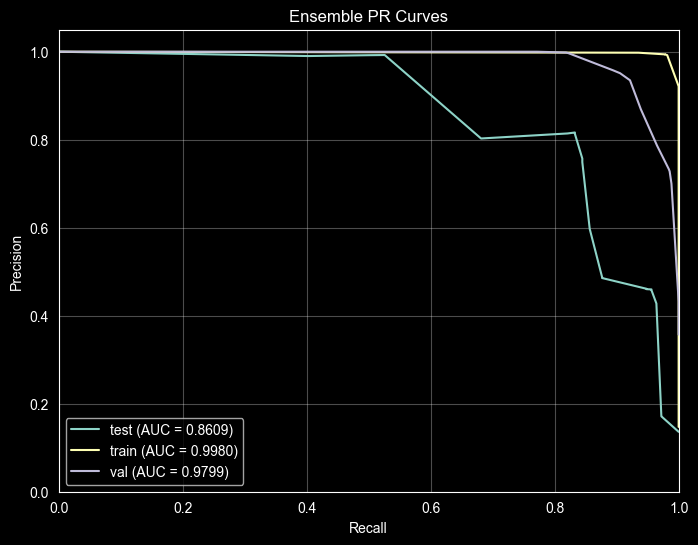

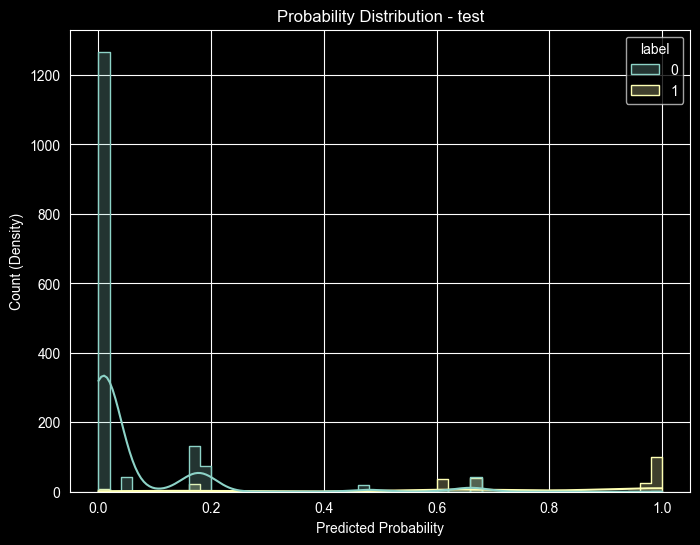

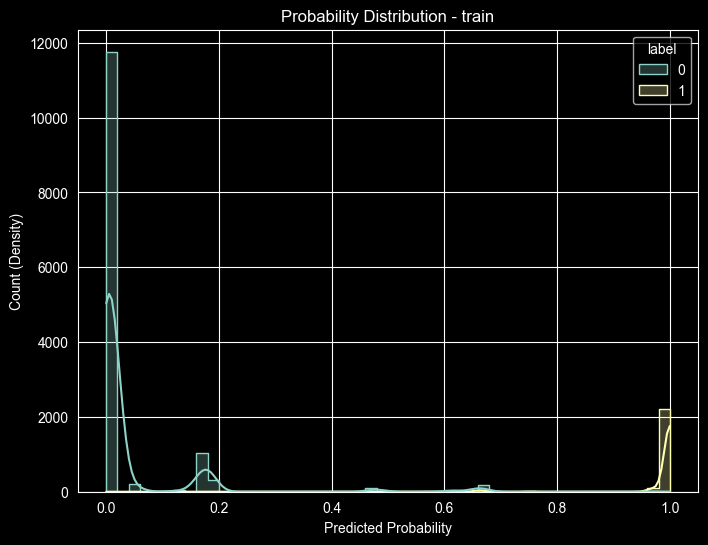

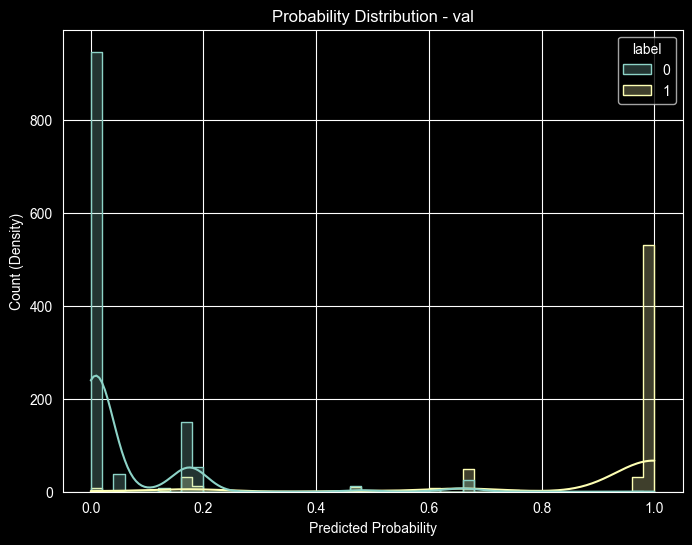


--- Confusion Matrices (Test Set) ---


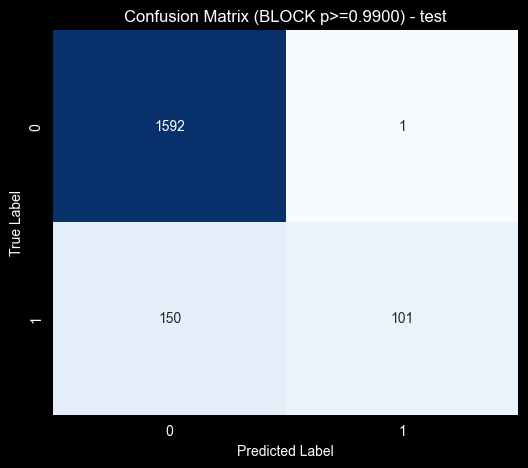

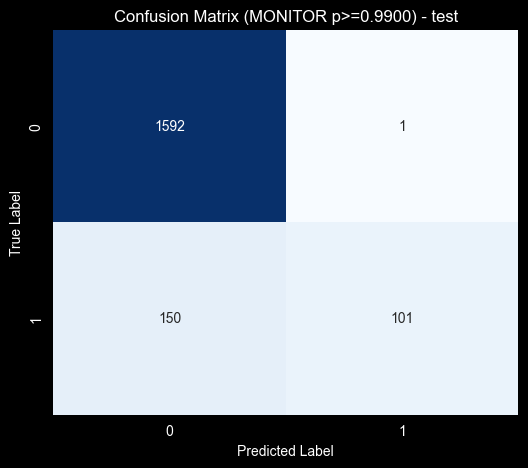

In [9]:
import json
# NEW: Import plotting functions here to avoid NameError
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions

# --- G) Final Model Performance Check (Post-Flight) ---
print("\n=== G) Final Model Performance Check (Post-Flight) ===")
# Load predictions from the main training run (Notebook 10)
preds_path = paths.artifacts_dir / "balanced_bagging" / "predictions.csv"
metrics_path = paths.artifacts_dir / "balanced_bagging" / "metrics.json"

if preds_path.exists() and metrics_path.exists():
    logger.info("Loading final ensemble predictions and metrics...")
    df_preds = pd.read_csv(preds_path)

    if "prob" in df_preds.columns:
        df_preds = df_preds.rename(columns={"prob": "p_calib"})
    elif "p_calib" not in df_preds.columns:
        raise ValueError("Missing calibrated probability column: expected 'prob' or 'p_calib'")

    if "prob_raw" in df_preds.columns:
        print("Raw and calibrated probabilities are both available.")

    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    # Get thresholds
    val_metrics = metrics.get("val", {})
    def get_thr(metrics_dict, fpr):
        key = f"fpr_{fpr}"
        if key in metrics_dict: return metrics_dict[key]["threshold"]
        return 0.99

    T_BLOCK = get_thr(val_metrics, 0.001)
    T_MONITOR = get_thr(val_metrics, 0.01)

    print(f"Global Thresholds: BLOCK={T_BLOCK:.4f}, MONITOR={T_MONITOR:.4f}")

    print("\n--- Ensemble ROC/PR Curves (All Splits) ---")
    plot_roc_curves(df_preds, prob_col="p_calib", title="Ensemble ROC Curves")
    plot_pr_curves(df_preds, prob_col="p_calib", title="Ensemble PR Curves")
    plot_probability_distributions(df_preds, prob_col="p_calib")

    print("\n--- Confusion Matrices (Test Set) ---")
    test_preds = df_preds[df_preds["split"] == "test"]
    plot_confusion_matrices(test_preds, prob_col="p_calib", threshold=T_BLOCK, title=f"Confusion Matrix (BLOCK p>={T_BLOCK:.4f})")
    plot_confusion_matrices(test_preds, prob_col="p_calib", threshold=T_MONITOR, title=f"Confusion Matrix (MONITOR p>={T_MONITOR:.4f})")
else:
    print("Final predictions not found. Run Notebook 10 to generate them.")